# Air Quality Data Exploration

This notebook performs exploratory data analysis on the historical hourly air-quality dataset for Delhi.

The data was collected from the Open-Meteo Air Quality API and contains hourly pollutant measurements for the year 2025.

### Objectives

- Load and inspect the raw air-quality dataset
- Examine dataset structure and data types
- Check missing values and duplicates
- Validate timestamps and hourly continuity
- Analyze pollutant distributions
- Examine monthly pollution patterns
- Study relationships between pollutants
- Identify potential extreme pollution events
- Summarize the key findings for further processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/raw/air_quality_delhi.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (8760, 7)


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2025-01-01 00:00:00,185.8,188.6,1645.0,56.7,49.7,31.0
1,2025-01-01 01:00:00,174.6,177.4,1551.0,44.8,39.7,39.0
2,2025-01-01 02:00:00,164.4,166.7,1478.0,34.6,31.5,46.0
3,2025-01-01 03:00:00,156.5,158.8,1418.0,26.7,26.0,52.0
4,2025-01-01 04:00:00,149.5,151.8,1379.0,20.6,22.3,57.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              8760 non-null   str    
 1   pm2_5             8760 non-null   float64
 2   pm10              8760 non-null   float64
 3   carbon_monoxide   8760 non-null   float64
 4   nitrogen_dioxide  8760 non-null   float64
 5   sulphur_dioxide   8760 non-null   float64
 6   ozone             8760 non-null   float64
dtypes: float64(6), str(1)
memory usage: 479.2 KB


In [4]:
df.columns.tolist()

['time',
 'pm2_5',
 'pm10',
 'carbon_monoxide',
 'nitrogen_dioxide',
 'sulphur_dioxide',
 'ozone']

In [5]:
df.describe()

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,80.291941,199.150742,864.171575,33.837283,30.627854,97.560502
std,45.879492,180.054789,578.033806,25.856685,16.850210,60.870635
min,6.000000,6.100000,176.000000,2.500000,8.100000,0.000000
25%,49.400000,78.000000,479.000000,15.200000,20.000000,50.000000
50%,70.500000,136.900000,675.000000,26.600000,26.100000,82.000000
75%,98.300000,251.725000,1071.000000,45.025000,36.200000,142.000000
max,369.700000,1438.000000,6889.000000,180.200000,185.800000,331.000000


In [6]:
df["time"] = pd.to_datetime(df["time"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              8760 non-null   datetime64[us]
 1   pm2_5             8760 non-null   float64       
 2   pm10              8760 non-null   float64       
 3   carbon_monoxide   8760 non-null   float64       
 4   nitrogen_dioxide  8760 non-null   float64       
 5   sulphur_dioxide   8760 non-null   float64       
 6   ozone             8760 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 479.2 KB


In [7]:
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

time                0
pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dtype: int64

Total missing values: 0


In [8]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [9]:
print(
    "Duplicate timestamps:",
    df["time"].duplicated().sum()
)

Duplicate timestamps: 0


In [10]:
print("Start:", df["time"].min())
print("End:", df["time"].max())

print("Unique timestamps:", df["time"].nunique())
print("Total rows:", len(df))

Start: 2025-01-01 00:00:00
End: 2025-12-31 23:00:00
Unique timestamps: 8760
Total rows: 8760


In [11]:
time_difference = df["time"].diff()

expected_interval = pd.Timedelta(hours=1)

unexpected_intervals = (
    time_difference.iloc[1:] != expected_interval
)

print(
    "Unexpected hourly intervals:",
    unexpected_intervals.sum()
)

Unexpected hourly intervals: 0


In [12]:
pollutants = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

In [13]:
df[pollutants].describe().T

,count,mean,std,min,25%,50%,75%,max
pm2_5,8760.0,80.291941,45.879492,6.0,49.4,70.5,98.300,369.7
pm10,8760.0,199.150742,180.054789,6.1,78.0,136.9,251.725,1438.0
carbon_monoxide,8760.0,864.171575,578.033806,176.0,479.0,675.0,1071.000,6889.0
nitrogen_dioxide,8760.0,33.837283,25.856685,2.5,15.2,26.6,45.025,180.2
sulphur_dioxide,8760.0,30.627854,16.850210,8.1,20.0,26.1,36.200,185.8
ozone,8760.0,97.560502,60.870635,0.0,50.0,82.0,142.000,331.0


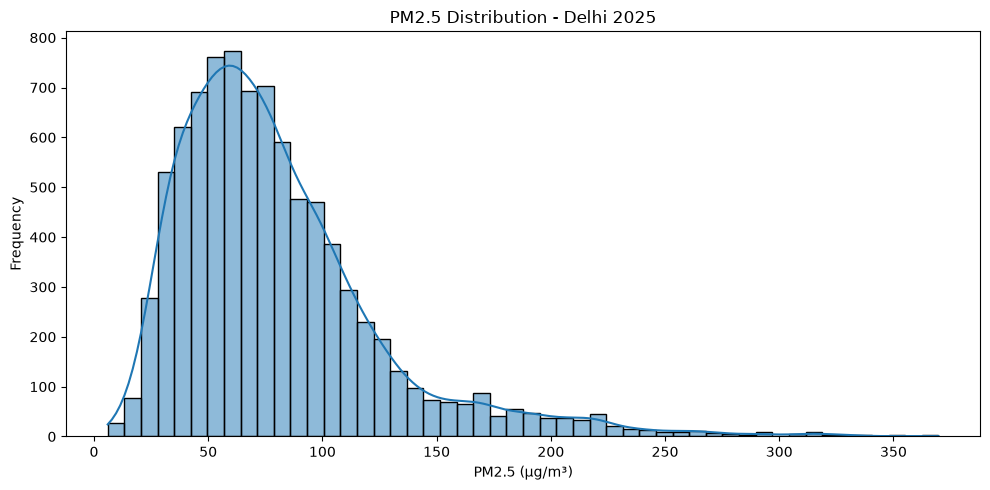

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["pm2_5"],
    bins=50,
    kde=True
)

plt.title("PM2.5 Distribution - Delhi 2025")
plt.xlabel("PM2.5 (μg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

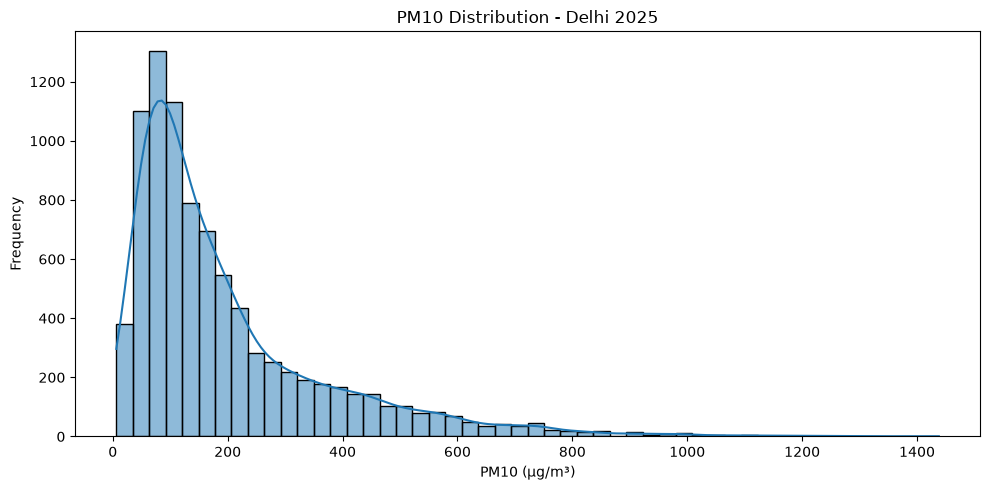

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["pm10"],
    bins=50,
    kde=True
)

plt.title("PM10 Distribution - Delhi 2025")
plt.xlabel("PM10 (μg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

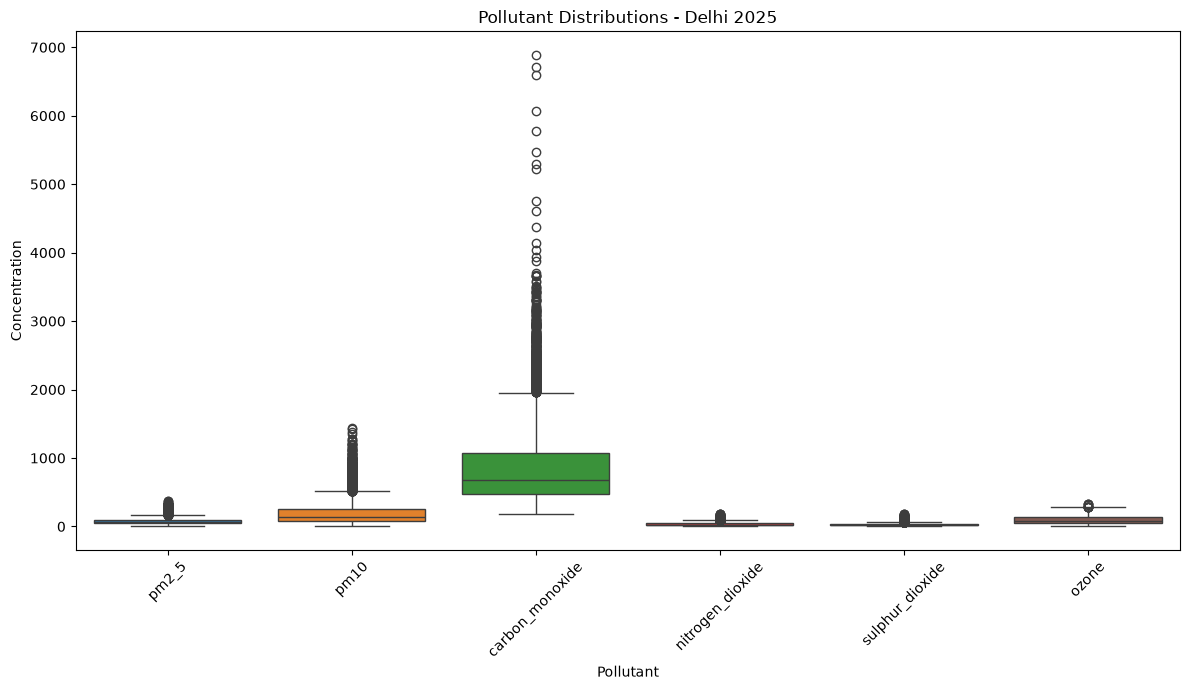

In [16]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=df[pollutants])

plt.title("Pollutant Distributions - Delhi 2025")
plt.xlabel("Pollutant")
plt.ylabel("Concentration")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

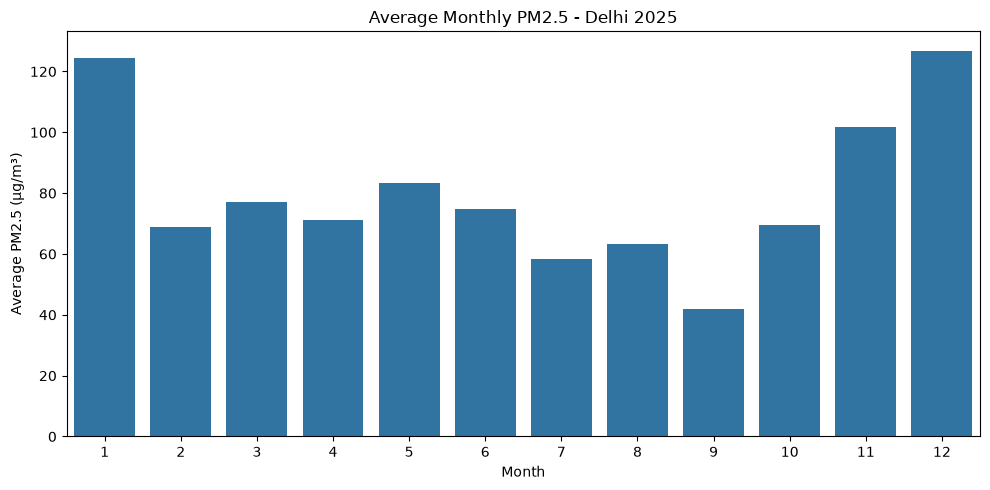

In [17]:
monthly_pm25 = (
    df.groupby(df["time"].dt.month)["pm2_5"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_pm25,
    x="time",
    y="pm2_5"
)

plt.title("Average Monthly PM2.5 - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (μg/m³)")

plt.tight_layout()
plt.show()

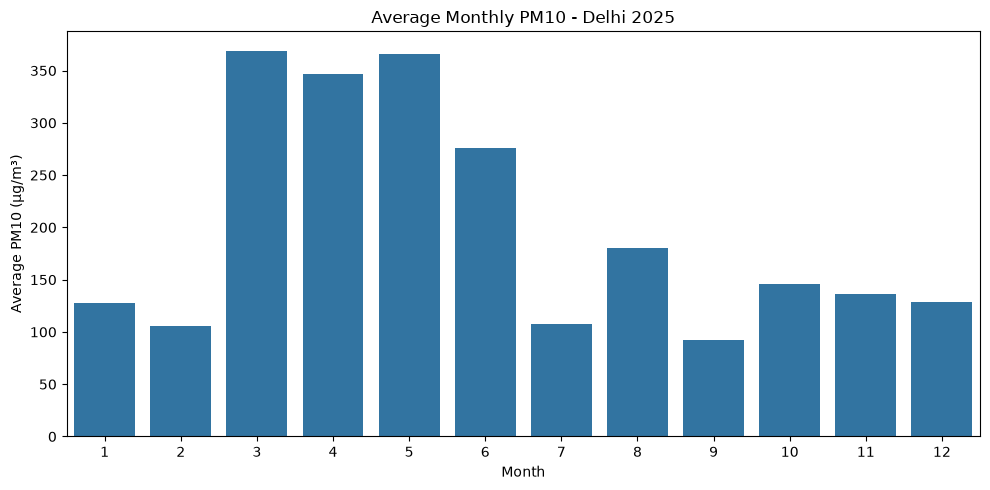

In [18]:
monthly_pm10 = (
    df.groupby(df["time"].dt.month)["pm10"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_pm10,
    x="time",
    y="pm10"
)

plt.title("Average Monthly PM10 - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Average PM10 (μg/m³)")

plt.tight_layout()
plt.show()

In [19]:
monthly_pollutants = (
    df.set_index("time")[pollutants]
      .resample("ME")
      .mean()
)

monthly_pollutants

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
time,,,,,,
2025-01-31,124.460215,127.734005,1514.927419,45.641398,45.262231,78.182796
2025-02-28,68.833631,106.143304,832.418155,31.801637,29.522173,81.450893
2025-03-31,77.246505,369.088978,663.653226,25.494489,23.750000,99.846774
2025-04-30,71.291667,346.311111,635.609722,20.507083,22.908472,130.840278
2025-05-31,83.255914,365.929839,615.526882,24.011022,24.263710,132.111559
2025-06-30,74.749861,276.260833,586.206944,25.693056,24.901944,122.069444
2025-07-31,58.230780,107.894086,671.868280,36.081989,28.069355,96.125000
2025-08-31,63.130511,179.939651,716.197581,34.772581,24.100672,79.884409
2025-09-30,42.026667,92.112639,557.075000,28.542639,21.778194,84.283333


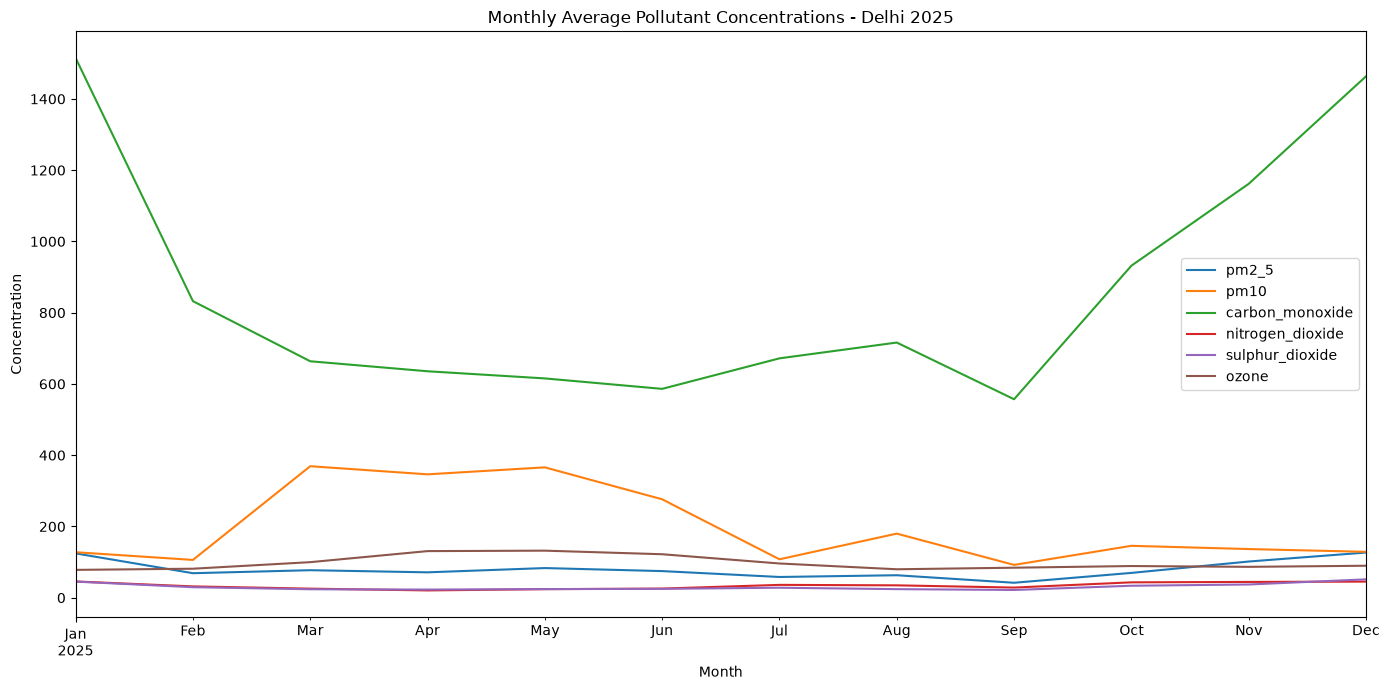

In [20]:
ax = monthly_pollutants.plot(
    figsize=(14, 7)
)

ax.set_title("Monthly Average Pollutant Concentrations - Delhi 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Concentration")

plt.tight_layout()
plt.show()

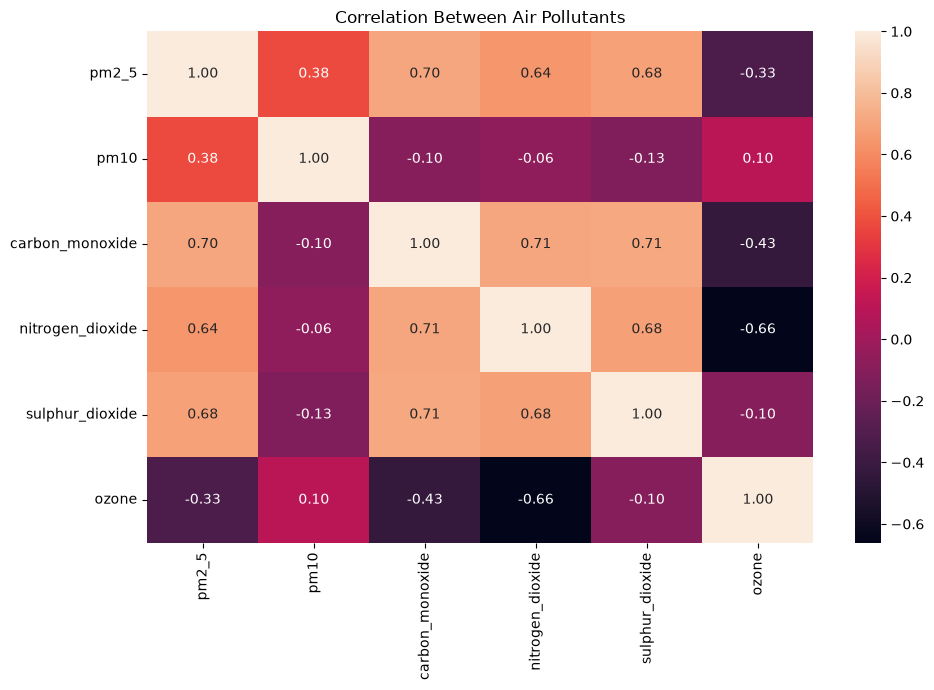

In [21]:
plt.figure(figsize=(10, 7))

correlation = df[pollutants].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Air Pollutants")

plt.tight_layout()
plt.show()

In [22]:
top_pm25 = (
    df.nlargest(10, "pm2_5")
)

top_pm25[
    ["time", "pm2_5", "pm10", "nitrogen_dioxide", "ozone"]
]

,time,pm2_5,pm10,nitrogen_dioxide,ozone
214,2025-01-09 22:00:00,369.7,374.4,177.8,6.0
215,2025-01-09 23:00:00,365.1,369.7,171.1,5.0
213,2025-01-09 21:00:00,354.8,356.7,180.2,9.0
216,2025-01-10 00:00:00,348.3,352.0,159.2,5.0
217,2025-01-10 01:00:00,334.3,339.0,143.0,7.0
8350,2025-12-14 22:00:00,333.4,337.1,143.3,30.0
8351,2025-12-14 23:00:00,329.7,334.3,132.1,27.0
8349,2025-12-14 21:00:00,328.8,333.4,154.2,34.0
212,2025-01-09 20:00:00,324.1,326.0,175.6,19.0
218,2025-01-10 02:00:00,324.1,327.8,128.7,10.0


In [23]:
top_pm10 = (
    df.nlargest(10, "pm10")
)

top_pm10[
    ["time", "pm2_5", "pm10", "nitrogen_dioxide", "ozone"]
]

,time,pm2_5,pm10,nitrogen_dioxide,ozone
1529,2025-03-05 17:00:00,186.3,1438.0,12.0,122.0
1530,2025-03-05 18:00:00,186.7,1419.3,12.2,116.0
1528,2025-03-05 16:00:00,177.9,1382.1,9.7,128.0
1527,2025-03-05 15:00:00,168.6,1348.6,6.8,135.0
1531,2025-03-05 19:00:00,177.4,1281.5,12.6,108.0
2104,2025-03-29 16:00:00,153.7,1274.0,10.5,154.0
2106,2025-03-29 18:00:00,163.4,1251.7,13.8,136.0
2107,2025-03-29 19:00:00,169.0,1244.2,16.0,124.0
2105,2025-03-29 17:00:00,153.2,1210.7,12.2,145.0
5249,2025-08-07 17:00:00,162.1,1210.7,16.9,103.0


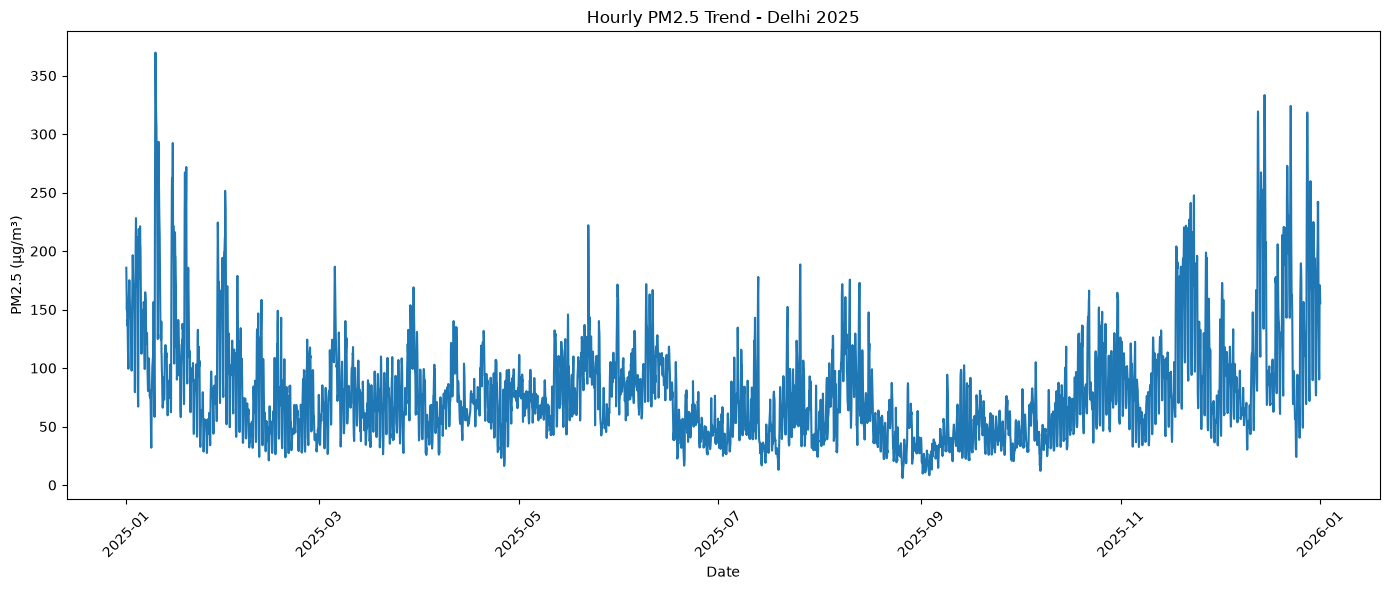

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["time"],
    df["pm2_5"]
)

plt.title("Hourly PM2.5 Trend - Delhi 2025")
plt.xlabel("Date")
plt.ylabel("PM2.5 (μg/m³)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Findings

- The air-quality dataset contains **8,760 hourly observations** covering the complete period from **January 1, 2025 to December 31, 2025**.

- The dataset contains **no missing values, duplicate rows, or duplicate timestamps**, and the hourly time series has no unexpected gaps.

- PM2.5 has an annual mean concentration of approximately **80.29 µg/m³**, with a maximum recorded value of **369.7 µg/m³**.

- PM10 has an annual mean concentration of approximately **199.15 µg/m³** and shows substantial variability, reaching a maximum of **1,438.0 µg/m³**.

- Carbon monoxide has a mean concentration of approximately **864.17 µg/m³**, while nitrogen dioxide, sulphur dioxide, and ozone have mean concentrations of approximately **33.84 µg/m³**, **30.63 µg/m³**, and **97.56 µg/m³**, respectively.

- The pollutant distributions show substantial variability and the presence of extreme pollution events. These observations should not automatically be treated as erroneous outliers because extreme pollution episodes are important for environmental-impact analysis.

- PM2.5 shows strong temporal variation throughout the year, with higher pollution levels occurring during several winter and post-monsoon periods.

- Monthly analysis indicates considerable seasonal variation in pollutant concentrations. PM2.5 reaches particularly high monthly averages in **January and December**, while lower average levels are observed during the monsoon period, especially around **September**.

- PM10 shows especially large monthly variations, with very high average concentrations during **March–May** compared with the monsoon months.

- The highest PM2.5 event occurred on **January 9, 2025**, reaching **369.7 µg/m³**. Several consecutive hours around this event also recorded very high PM10 and nitrogen dioxide concentrations.

- The highest PM10 event occurred on **March 5, 2025**, reaching **1,438.0 µg/m³**, indicating a significant short-duration pollution episode.

- Overall, the air-quality dataset is **complete and structurally suitable for further processing**. The observed seasonal variation and extreme pollution events provide valuable information for the development of the Climate Impact Dashboard.

### EDA Conclusion

The exploratory analysis shows that Delhi experienced substantial temporal and seasonal variation in air pollution during 2025. Extreme pollution events are present in the dataset and should be preserved for further analysis rather than removed solely because they appear as statistical outliers. The next stage will focus on validating pollutant values, preparing the air-quality data for integration, and combining it with the cleaned weather dataset.